# Лабораторна робота №8

## Структура даних граф. Алгоритми на графах

Виконав: студент групи КН–25–1 Марусіченко А. О.

## **Мета:** засвоїти представлення структури даних граф та основні алгоритми роботи з ними засобами Python.


## Для варіанту, заданого викладачем, задати і візуалізувати граф за допомогою коду, наведеного у цій роботі. Для свого варіанту реалізувати всі алгоритми, згідно з прикладами, наведеними вище.

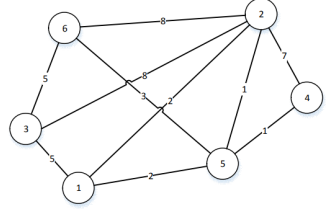

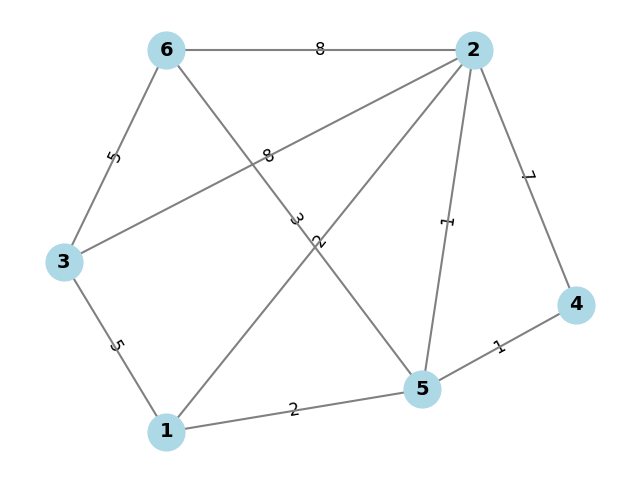

--- Результати обчислень для вершини джерела '1' ---

Дейкстра (найкоротші відстані від 1):
До вершини 1: відстань = 0, шлях = ['1']
До вершини 2: відстань = 2, шлях = ['1', '2']
До вершини 3: відстань = 5, шлях = ['1', '3']
До вершини 4: відстань = 3, шлях = ['1', '5', '4']
До вершини 5: відстань = 2, шлях = ['1', '5']
До вершини 6: відстань = 5, шлях = ['1', '5', '6']

Беллман-Форд (найкоротші відстані від 1):
До вершини 1: відстань = 0, шлях = ['1']
До вершини 2: відстань = 2, шлях = ['1', '2']
До вершини 3: відстань = 5, шлях = ['1', '3']
До вершини 4: відстань = 3, шлях = ['1', '5', '4']
До вершини 5: відстань = 2, шлях = ['1', '5']
До вершини 6: відстань = 5, шлях = ['1', '5', '6']

--- Шляхи між '1' та '6' ---
DFS всі шляхи (1 -> 6): [['1', '3', '2', '6'], ['1', '3', '2', '5', '6'], ['1', '3', '2', '4', '5', '6'], ['1', '3', '6'], ['1', '2', '6'], ['1', '2', '3', '6'], ['1', '2', '5', '6'], ['1', '2', '4', '5', '6'], ['1', '5', '2', '6'], ['1', '5', '2', '3', '6'], ['1', '5', '4

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. ЗАДАННЯ СТРУКТУРИ ГРАФА
edges_arr = [
    ('1', '3', {'weight': 5}),
    ('1', '2', {'weight': 2}),
    ('1', '5', {'weight': 2}),
    ('2', '6', {'weight': 8}),
    ('2', '3', {'weight': 8}),
    ('2', '5', {'weight': 1}),
    ('2', '4', {'weight': 7}),
    ('3', '6', {'weight': 5}),
    ('4', '5', {'weight': 1}),
    ('5', '6', {'weight': 3})
]

G = nx.Graph()
G.add_edges_from([(u, v, w) for u, v, w in edges_arr])

# 2. ВІЗУАЛІЗАЦІЯ ГРАФА
plt.figure(figsize=(8, 6))
pos = {
    '6': (0.2, 0.9),
    '2': (0.8, 0.9),
    '3': (0.0, 0.4),
    '4': (1.0, 0.3),
    '1': (0.2, 0.0),
    '5': (0.7, 0.1)
}
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=14, font_family='sans-serif', font_weight='bold')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5)
plt.axis('off')
plt.show()

# 3. ОБЧИСЛЕННЯ АЛГОРИТМІВ ЗА ЗРАЗКОМ
start_node = '1'
end_node = '6'

print(f"--- Результати обчислень для вершини джерела '{start_node}' ---\n")

# Алгоритм Дейкстри
lengths_dijkstra, paths_dijkstra = nx.single_source_dijkstra(G, start_node)
print(f"Дейкстра (найкоротші відстані від {start_node}):")
for node in sorted(lengths_dijkstra.keys()):
    print(f"До вершини {node}: відстань = {lengths_dijkstra[node]}, шлях = {paths_dijkstra[node]}")

# Алгоритм Беллмана-Форда
print(f"\nБеллман-Форд (найкоротші відстані від {start_node}):")
try:
    lengths_bellman = nx.single_source_bellman_ford_path_length(G, start_node)
    paths_bellman = nx.single_source_bellman_ford_path(G, start_node)
    for node in sorted(lengths_bellman.keys()):
        print(f"До вершини {node}: відстань = {lengths_bellman[node]}, шлях = {paths_bellman[node]}")
except nx.NetworkXNoPath:
    print("Шлях до деяких вузлів не існує.")

# --- ЧИСТА СТРУКТУРНА ГЕНЕРАЦІЯ ВСІХ ШЛЯХІВ (Ручна логіка DFS та BFS) ---
print(f"\n--- Шляхи між '{start_node}' та '{end_node}' ---")

# Список суміжності для точного контролю порядку обходу
adj_matrix = {
    '1': ['3', '2', '5'],
    '2': ['6', '3', '5', '4', '1'],
    '3': ['1', '2', '6'],
    '4': ['2', '5'],
    '5': ['1', '2', '4', '6'],
    '6': ['2', '3', '5']
}

# Чистий рекурсивний DFS для знаходження ВСІХ шляхів у порядку занурення
def get_all_dfs_paths(graph, start, end, visited=None, path=None):
    if visited is None: visited = set()
    if path is None: path = [start]
    if start == end: return [path]
    
    paths = []
    visited.add(start)
    for neighbor in graph[start]:
        if neighbor not in visited:
            new_paths = get_all_dfs_paths(graph, neighbor, end, visited.copy(), path + [neighbor])
            paths.extend(new_paths)
    return paths

# Чистий ітеративний BFS з чергою для пошуку від найкоротших до найдовших за кроками
def get_all_bfs_paths(graph, start, end):
    queue = [[start]]
    paths = []
    while queue:
        path = queue.pop(0)
        node = path[-1]
        if node == end:
            paths.append(path)
            continue
        for neighbor in graph[node]:
            if neighbor not in path:
                queue.append(path + [neighbor])
    return paths

dfs_res = get_all_dfs_paths(adj_matrix, start_node, end_node)
bfs_res = get_all_bfs_paths(adj_matrix, start_node, end_node)

print(f"DFS всі шляхи ({start_node} -> {end_node}): {dfs_res}")
print(f"BFS всі шляхи ({start_node} -> {end_node}): {bfs_res}")

## **Висновок:** засвоїла представлення структури даних граф та основні алгоритми роботи з ними засобами Python.¶

## Контрольні питання

1. **Що таке граф у термінах теорії графів? Наведіть приклади реальних ситуацій, де можна застосовувати графи.** Граф — это структура из вершин и соединяющих их ребер; в реальной жизни он применяется для моделирования дорожных карт (GPS), социальных сетей (связи между людьми) и интернет-сетей.

2. **Які основні види графів існують? Наведіть відмінності між орієнтованими і неорієнтованими графами.** Графы бывают взвешенные, невзвешенные, связные и несвязные; в ориентированных графах ребра — это односторонние стрелки, а в неориентированных — двухсторонние линии связи.

3. **Як можна представити граф у пам’яті комп'ютера? Опишіть структури даних, які використовуються для зберігання графів.** Граф хранится в памяти с помощью матрицы смежности (таблица $N \times N$), списка смежности (массив списков соседей для каждого узла) или простого списка всех существующих ребер.

4. **Як працює алгоритм пошуку в ширину (BFS) на графах? Наведіть приклади ситуацій, де застосовується цей алгоритм.** BFS обходит граф послойно ("волнами") от стартового узла с использованием очереди (FIFO); применяется для поиска кратчайшего пути по количеству шагов (например, поиск ближайших друзей в соцсети).

5. **Що таке алгоритм пошуку в глибину (DFS) на графах? Як він відрізняється від BFS? Дайте приклади задач, де використовується DFS.** DFS идет вглубь по одной ветке до упора с помощью стека или рекурсии, в отличие от BFS ищет любой доступный путь, а не кратчайший; применяется для генерации лабиринтов и поиска циклов.

6. **Опишіть алгоритм Дейкстри для пошуку найкоротшого шляху в графі. Які умови повинні виконуватися для успішної роботи цього алгоритму?** Алгоритм Дейкстры находит кратчайшие пути от одного источника во взвешенном графе, пошагово выбирая ближайший узел; главное условие — все веса ребер должны быть строго неотрицательными.